In [1]:
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=57f670795b76e246c3c114f9b2f7eb928c0120d82d4de3c7071b30379dc5fee9
  Stored in directory: /root/.cache/pip/wheels/be/33/77/b6bb14008fa79a2dd2b79d565e941d5faa2d7f7526e528345b
Successfully built minisom


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Dataset Path
data_dir = "/kaggle/input/swedishleaf/SwedishLeaf"

# Image Parameters
img_size = (64, 64)  # Resize to 64x64 to reduce computation
batch_size = 32

# Data Preprocessing (Convert Images to Features)
datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2  # 80% Train, 20% Test
)

# Load Images
train_data = datagen.flow_from_directory(
    data_dir, target_size=img_size, batch_size=batch_size,
    class_mode="categorical", subset="training", shuffle=True
)

test_data = datagen.flow_from_directory(
    data_dir, target_size=img_size, batch_size=batch_size,
    class_mode="categorical", subset="validation", shuffle=False
)

# Convert Images to Feature Vectors
def extract_features(data_generator):
    """Extracts images as flattened feature vectors and labels."""
    X, y = [], []
    
    for i in range(len(data_generator)):
        images, labels = data_generator[i]
        for img, label in zip(images, labels):
            X.append(img.flatten())  # Flatten 64x64x3 → 12288D
            y.append(np.argmax(label))  # Convert one-hot to class index
    
    return np.array(X), np.array(y)

# Extract Features from Images
X, y = extract_features(train_data)
X_test, y_test = extract_features(test_data)

# Normalize Data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

#Train SOM Features
som_size = (20, 20)  # 20x20 SOM Grid
som = MiniSom(som_size[0], som_size[1], X_scaled.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, 1000)  # Train SOM for 5000 iterations

X_bmu = np.array([som.winner(x) for x in X_scaled])  # Shape: (n_samples, 2)
X_test_bmu = np.array([som.winner(x) for x in X_test_scaled])  # Shape: (n_samples, 2)


X_act = np.array([som.activation_response(x.reshape(1, -1)).flatten() for x in X_scaled])  # Shape: (n_samples, 400)
X_test_act = np.array([som.activation_response(x.reshape(1, -1)).flatten() for x in X_test_scaled])  # Shape: (n_samples, 400)


X_orig = X_scaled  # Original 12288D Features
X_test_orig = X_test_scaled


# Train on BMU Features (2D)
svm_bmu = SVC(kernel='rbf')
svm_bmu.fit(X_bmu, y)
y_pred_bmu = svm_bmu.predict(X_test_bmu)

# Train on Activation Response Features (400D)
svm_act = SVC(kernel='rbf')
svm_act.fit(X_act, y)
y_pred_act = svm_act.predict(X_test_act)

# Train on Original Features (12288D)
svm_orig = SVC(kernel='rbf')
svm_orig.fit(X_orig, y)
y_pred_orig = svm_orig.predict(X_test_orig)


accuracy_bmu = accuracy_score(y_test, y_pred_bmu)
accuracy_act = accuracy_score(y_test, y_pred_act)
accuracy_orig = accuracy_score(y_test, y_pred_orig)

# Store Results for Comparison
comparison_results = {
    "Feature Type": ["BMU Coordinates (2D)", "Activation Responses (400D)", "Original Features (12288D)"],
    "SVM Accuracy": [accuracy_bmu, accuracy_act, accuracy_orig]
}

# Convert to DataFrame and Print Results
results_df = pd.DataFrame(comparison_results)
print(results_df)


Found 600 images belonging to 10 classes.
Found 150 images belonging to 10 classes.
                  Feature Type  SVM Accuracy
0         BMU Coordinates (2D)      0.533333
1  Activation Responses (400D)      0.800000
2   Original Features (12288D)      0.926667


In [3]:
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=84186874689e21619472282610ac78df450d108676b386a535d00e2807556dac
  Stored in directory: /root/.cache/pip/wheels/be/33/77/b6bb14008fa79a2dd2b79d565e941d5faa2d7f7526e528345b
Successfully built minisom


In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset Path
data_dir = "/kaggle/input/swedishleaf/SwedishLeaf"

# Image Parameters
img_size = (64, 64)  
batch_size = 32

# Data Preprocessing
datagen = ImageDataGenerator(rescale=1.0 / 255.0, validation_split=0.2)

# Load Images
train_data = datagen.flow_from_directory(
    data_dir, target_size=img_size, batch_size=batch_size,
    class_mode="categorical", subset="training", shuffle=True
)

test_data = datagen.flow_from_directory(
    data_dir, target_size=img_size, batch_size=batch_size,
    class_mode="categorical", subset="validation", shuffle=False
)

# Convert Images to Feature Vectors
def extract_features(data_generator):
    """Extracts images as flattened feature vectors and labels."""
    X, y = [], []
    for i in range(len(data_generator)):
        images, labels = data_generator[i]
        for img, label in zip(images, labels):
            X.append(img.flatten())  # Flatten 64x64x3 → 12288D
            y.append(np.argmax(label))  # Convert one-hot to class index
    return np.array(X), np.array(y)

# Extract Features
X, y = extract_features(train_data)
X_test, y_test = extract_features(test_data)

# Normalize Data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# ---------------- Step 1: Train SOM & Track Loss ----------------
som_size = (20, 20)  
som = MiniSom(som_size[0], som_size[1], X_scaled.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_scaled)

training_loss = []
for i in range(1000):  # Train for 1000 iterations
    sample = X_scaled[np.random.randint(0, len(X_scaled))]
    som.update(sample, som.winner(sample), i, 1000)
    
    # ✅ FIXED: Compute loss using BMU weights, not BMU coordinates
    loss = np.mean([np.linalg.norm(som.get_weights()[som.winner(x)] - x) for x in X_scaled])
    training_loss.append(loss)

# ---------------- Step 2: Extract SOM Features ----------------
X_bmu = np.array([som.winner(x) for x in X_scaled])  # (n_samples, 2)
X_test_bmu = np.array([som.winner(x) for x in X_test_scaled])

X_act = np.array([som.activation_response(x.reshape(1, -1)).flatten() for x in X_scaled])  # (n_samples, 400)
X_test_act = np.array([som.activation_response(x.reshape(1, -1)).flatten() for x in X_test_scaled])

X_orig = X_scaled  
X_test_orig = X_test_scaled

# ---------------- Step 3: Train SVM Classifiers ----------------
svm_bmu = SVC(kernel='rbf')
svm_bmu.fit(X_bmu, y)
y_pred_bmu = svm_bmu.predict(X_test_bmu)

svm_act = SVC(kernel='rbf')
svm_act.fit(X_act, y)
y_pred_act = svm_act.predict(X_test_act)

svm_orig = SVC(kernel='rbf')
svm_orig.fit(X_orig, y)
y_pred_orig = svm_orig.predict(X_test_orig)

# Compute Accuracy
accuracy_bmu = accuracy_score(y_test, y_pred_bmu)
accuracy_act = accuracy_score(y_test, y_pred_act)
accuracy_orig = accuracy_score(y_test, y_pred_orig)

# Store Results for Comparison
comparison_results = {
    "Feature Type": ["BMU Coordinates (2D)", "Activation Responses (400D)", "Original Features (12288D)"],
    "SVM Accuracy": [accuracy_bmu, accuracy_act, accuracy_orig]
}

results_df = pd.DataFrame(comparison_results)
print(results_df)

# ---------------- Step 4: Plot SOM Training Loss ----------------
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(training_loss, label="SOM Training Loss", color="red")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("SOM Training Loss Over Time")
plt.legend()

# ---------------- Step 5: Plot SVM Accuracy Comparison ----------------
plt.subplot(1, 2, 2)
plt.bar(results_df["Feature Type"], results_df["SVM Accuracy"], color=["blue", "green", "orange"])
plt.xlabel("Feature Type")
plt.ylabel("Accuracy")
plt.ylim(0, 1)  
plt.title("SVM Accuracy on Different Feature Representations")
plt.xticks(rotation=15)

plt.show()

# ---------------- Step 6: SOM Projection Map ----------------
plt.figure(figsize=(10, 8))
plt.title("Projection onto SOM")

# Define Colors for Each Class
colors = ["red", "blue", "green", "yellow", "orange", "purple", "cyan", "pink", "brown", "black"]

# Assign Colors to Each Class
for i, x in enumerate(X_scaled):
    winner = som.winner(x)
    plt.plot(winner[0] + 0.5, winner[1] + 0.5, "o", markerfacecolor=colors[y[i]], 
             markeredgecolor="black", markersize=8, alpha=0.7)

# SOM Grid
for i in range(som_size[0]):
    for j in range(som_size[1]):
        plt.plot(i + 0.5, j + 0.5, "o", markerfacecolor="white", markeredgecolor="gray", markersize=5, alpha=0.3)

# Add Class Labels Legend
for i, color in enumerate(colors):
    plt.plot([], [], "o", markerfacecolor=color, markersize=8, label=f"Class {i}")
plt.legend(title="Groups")

plt.show()


Found 600 images belonging to 10 classes.
Found 150 images belonging to 10 classes.


Found 750 images belonging to 10 classes.


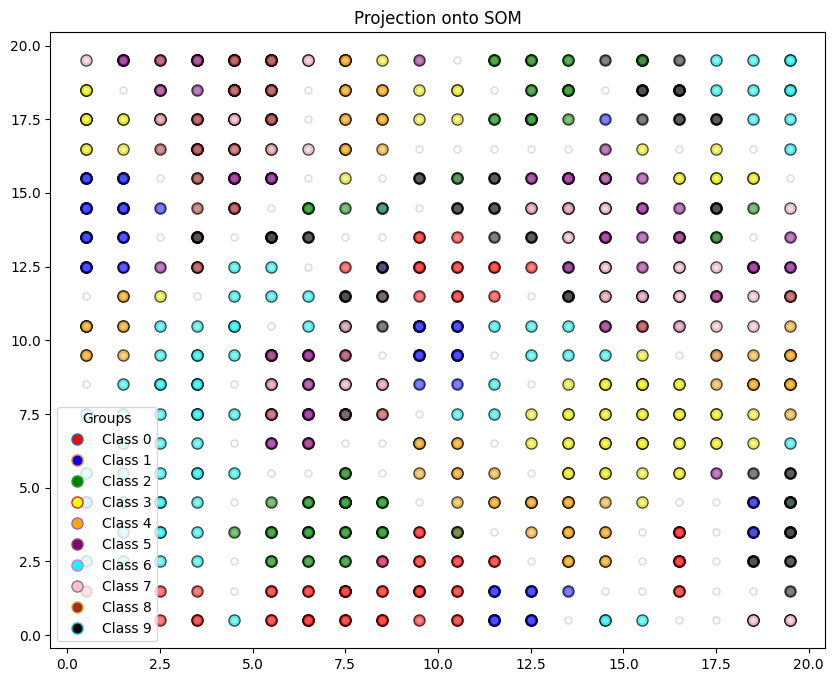

In [4]:
!pip install minisom
import os
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset Path
data_dir = "/kaggle/input/swedishleaf/SwedishLeaf"

# Image Parameters
img_size = (64, 64)  
batch_size = 32  

# Data Preprocessing
datagen = ImageDataGenerator(rescale=1.0 / 255.0)

# Load Images
data_generator = datagen.flow_from_directory(
    data_dir, target_size=img_size, batch_size=batch_size,
    class_mode="categorical", shuffle=True
)

# Convert Images to Feature Vectors
def extract_features(data_generator):
    """Extracts images as flattened feature vectors and labels."""
    X, y = [], []
    
    for i in range(len(data_generator)):
        images, labels = data_generator[i]
        for img, label in zip(images, labels):
            X.append(img.flatten())  # Flatten 64x64x3 → 12288D
            y.append(np.argmax(label))  # Convert one-hot to class index
    
    return np.array(X), np.array(y)

# Extract Features
X, y = extract_features(data_generator)

# Normalize Data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train SOM
som_size = (20, 20)  # 20x20 SOM Grid
som = MiniSom(som_size[0], som_size[1], X_scaled.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_scaled)
som.train_random(X_scaled, 5000)  # Train SOM for 5000 iterations

# Plot SOM Projection
plt.figure(figsize=(10, 8))
plt.title("Projection onto SOM")

# Define Colors for Each Class
colors = ["red", "blue", "green", "yellow", "orange", "purple", "cyan", "pink", "brown", "black"]

# Assign Colors to Each Class
for i, x in enumerate(X_scaled):
    winner = som.winner(x)  # Get BMU (Best Matching Unit)
    plt.plot(winner[0] + 0.5, winner[1] + 0.5, "o", markerfacecolor=colors[y[i]], 
             markeredgecolor="black", markersize=8, alpha=0.7)

# Plot SOM Grid
for i in range(som_size[0]):
    for j in range(som_size[1]):
        plt.plot(i + 0.5, j + 0.5, "o", markerfacecolor="white", markeredgecolor="gray", markersize=5, alpha=0.3)

# Add Class Labels Legend
for i, color in enumerate(colors):
    plt.plot([], [], "o", markerfacecolor=color, markersize=8, label=f"Class {i}")
plt.legend(title="Groups")

plt.show()
